In [ ]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim


import matplotlib.pyplot as plt

In [ ]:
image_barbabra = cv2.imread('/content/barbara.png', cv2.IMREAD_GRAYSCALE)
image_pepper = cv2.imread('/content/peppers.png', cv2.IMREAD_GRAYSCALE)

### Bài 1

#### Salt and pepper Noise

In [ ]:
def add_salt_and_pepper_noise(image, prob):
  noise_image = image.copy()
  total_pixel = image.size

  # Thêm nhiễu muỗi
  num_salt = int(total_pixel * prob) # Tính toán số lượng nhiễu salt
  salt_coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape[:2]]
  noise_image[salt_coords[0], salt_coords[1]] = 255

  # Thêm nhiễu tiêu
  num_pepper = int(total_pixel * prob) # Tính toán số lượng nhiễu pepper
  pepper_coords = [np.random.randint(0, i - 1, ) for i in image.shape[:2]]
  noise_image[salt_coords[0], pepper_coords[1]] = 0
  return noise_image

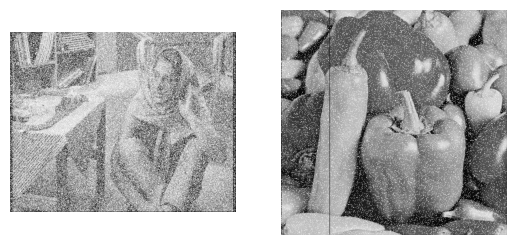

In [ ]:
noisy_image_1 = add_salt_and_pepper_noise(image_barbabra, 0.5)
noisy_image_2 = add_salt_and_pepper_noise(image_pepper, 0.1)

plt.subplot(1, 2, 1)  # Ảnh đầu tiên ở vị trí 1
plt.imshow(noisy_image_1, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)  # Ảnh thứ hai ở vị trí 2
plt.imshow(noisy_image_2, cmap='gray')
plt.axis('off')

plt.show()

#### Gaussian Noise

In [ ]:
def add_gaussian_noise(image, mean=0, stddev=25):
    """
    Thêm nhiễu Gaussian vào ảnh.

    - mean: Giá trị trung bình của nhiễu.
    - stddev: Độ lệch chuẩn của nhiễu.
    """
    gaussian_noise = np.random.normal(mean, stddev, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, gaussian_noise)  # Cộng nhiễu vào ảnh gốc
    return noisy_image

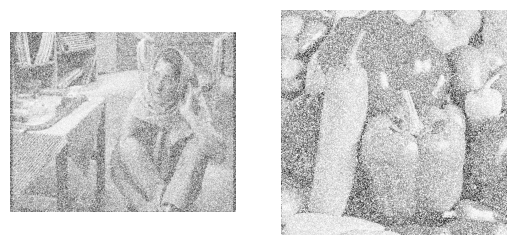

In [ ]:
noisy_image_gaussian_1 = add_gaussian_noise(image_barbabra, mean=0, stddev=25)
noisy_image_gaussian_2 = add_gaussian_noise(image_pepper, mean=0, stddev=25)

plt.subplot(1, 2, 1)  # Ảnh đầu tiên ở vị trí 1
plt.imshow(noisy_image_gaussian_1, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)  # Ảnh thứ hai ở vị trí 2
plt.imshow(noisy_image_gaussian_2, cmap='gray')
plt.axis('off')

plt.show()

#### Speckle Noise

In [ ]:
def add_speckle_noise(image, var=0.1):
    """
    Thêm nhiễu Speckle vào ảnh.

    - var: Hệ số điều chỉnh mức độ nhiễu.
    """
    noise = np.random.randn(*image.shape) * var  # Nhiễu Gaussian ngẫu nhiên
    noisy_image = image + image * noise  # Nhiễu nhân bản
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)  # Giữ giá trị hợp lệ
    return noisy_image

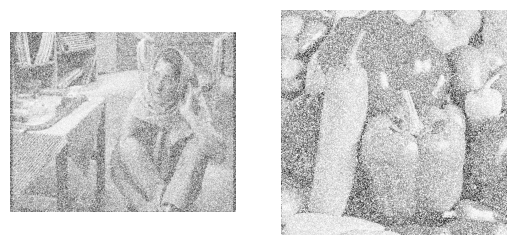

In [ ]:
noisy_image_speckle_1 = add_speckle_noise(image_barbabra, var=0.05)
noisy_image_speckle_2 = add_speckle_noise(image_pepper, var=0.05)

plt.subplot(1, 2, 1)  # Ảnh đầu tiên ở vị trí 1
plt.imshow(noisy_image_gaussian_1, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)  # Ảnh thứ hai ở vị trí 2
plt.imshow(noisy_image_gaussian_2, cmap='gray')
plt.axis('off')

plt.show()

### Bài 2

In [ ]:
def median_filter(image, kernel_size=3):
    """Apply a median filter manually to an image."""
    # Padding to maintain image size
    pad = kernel_size // 2
    padded_img = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    filtered_img = np.zeros_like(image)

    # Loop over each pixel (excluding padding)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Extract neighborhood
            window = padded_img[i:i+kernel_size, j:j+kernel_size].flatten()

            # Compute the median and replace the pixel
            filtered_img[i, j] = np.median(window)

    return filtered_img

#### Nhận xét:
| **Bộ lọc**         | **Hiệu quả giảm nhiễu**   | **Tác dụng phụ**        |
|--------------------|-----------------------|-----------------------|
| Averaging 3x3    | Giảm nhiễu nhẹ         | Làm mờ nhẹ ảnh        |
| Averaging 7x7    | Giảm nhiễu nhiều hơn   | Ảnh bị mờ nhiều hơn   |


### Bài 3

#### **Median filter**

In [ ]:
def median_filter(image, kernel_size=3):
    """ Áp dụng bộ lọc trung vị thủ công cho ảnh xám """
    pad = kernel_size // 2  # Kích thước lề cần padding
    padded_image = np.pad(image, pad, mode='constant', constant_values=0)  # Thêm padding 0
    filtered_image = np.zeros_like(image)  # Tạo ảnh kết quả rỗng

    # Duyệt từng pixel trong ảnh gốc
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Lấy vùng lân cận (kernel window)
            window = padded_image[i:i+kernel_size, j:j+kernel_size]
            # Lấy giá trị trung vị
            median_value = np.median(window)
            # Gán giá trị trung vị vào ảnh kết quả
            filtered_image[i, j] = median_value

    return filtered_image

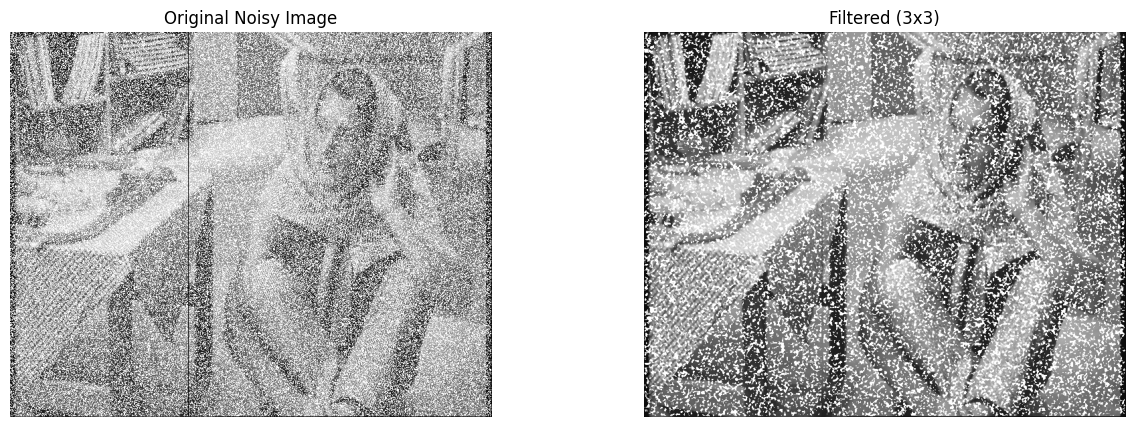

In [ ]:
filtered_median_blur_3x3 = median_filter(noisy_image_1, kernel_size=3)
# Hiển thị kết quả
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title("Original Noisy Image")
plt.imshow(noisy_image_1, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Filtered (3x3)")
plt.imshow(filtered_median_blur_3x3, cmap="gray")
plt.axis("off")


plt.show()

#### **Weight median filter**

In [ ]:
def add_weighted_median_filter(image, kernel, kernel_size):
  padded_img = cv2.copyMakeBorder(image, kernel_size//2, kernel_size//2, kernel_size//2, kernel_size//2, cv2.BORDER_REPLICATE)
  filtered_img = np.zeros_like(image)

  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        # Lấy vùng lân cận
        window = padded_img[i:i+kernel_size, j:j+kernel_size].flatten()
        weights = kernel.flatten()

        # Tạo danh sách lặp lại giá trị theo trọng số
        weighted_values = np.repeat(window, weights)

        # Tìm trung vị
        filtered_img[i, j] = np.median(weighted_values)

  return filtered_img

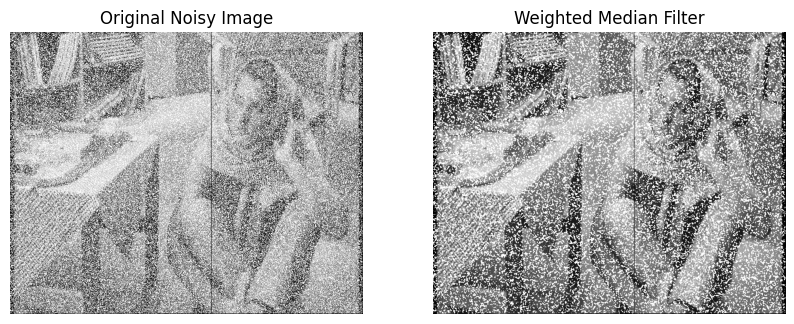

In [ ]:
# Kernel trọng số (3x3)
weight_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
])
# Áp dụng bộ lọc trung vị có trọng số
weighted_median_img = add_weighted_median_filter(noisy_image_1, weight_kernel, 3)

# Hiển thị ảnh
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Noisy Image")
plt.imshow(noisy_image_1, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Weighted Median Filter")
plt.imshow(weighted_median_img, cmap="gray")
plt.axis("off")

plt.show()

#### **Outlier Method**

In [ ]:
def outlier_filter(image, threshold=30):
    """Loại bỏ pixel nhiễu bằng cách phát hiện ngoại lai và thay thế bằng trung vị."""
    filtered_image = image.copy()
    h, w = image.shape

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            # Lấy giá trị pixel hiện tại
            pixel_value = image[i, j]

            # Lấy vùng lân cận (3x3)
            neighbors = image[i-1:i+2, j-1:j+2].flatten()

            # Tính giá trị trung bình (không tính pixel gốc)
            median_value = np.median(neighbors)

            # Nếu pixel là ngoại lai (khác quá nhiều so với trung vị)
            if abs(int(pixel_value) - int(median_value)) > threshold:
                filtered_image[i, j] = median_value  # Thay thế bằng trung vị

    return filtered_image

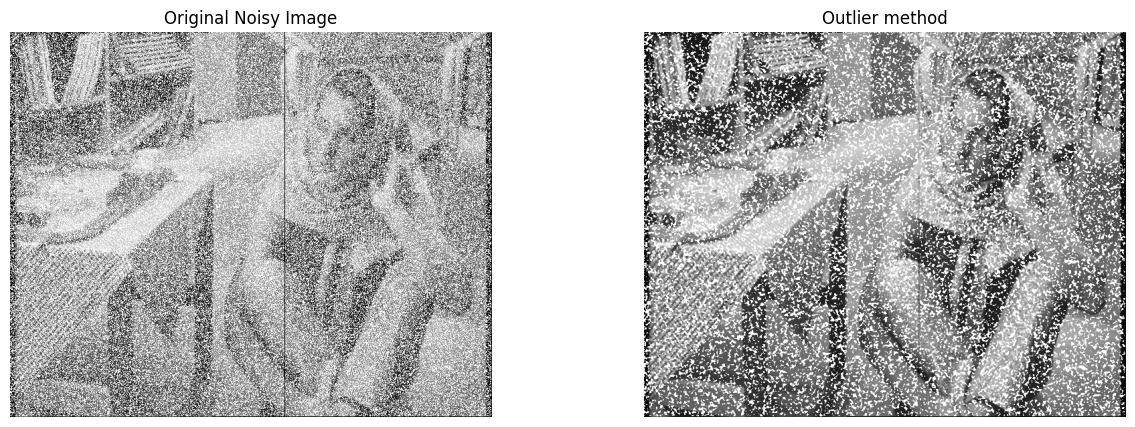

In [ ]:
filtered_outlier_image = outlier_filter(noisy_image_1, threshold=30)
# Hiển thị kết quả
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title("Original Noisy Image")
plt.imshow(noisy_image_1, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Outlier method")
plt.imshow(filtered_outlier_image, cmap="gray")
plt.axis("off")
plt.show()

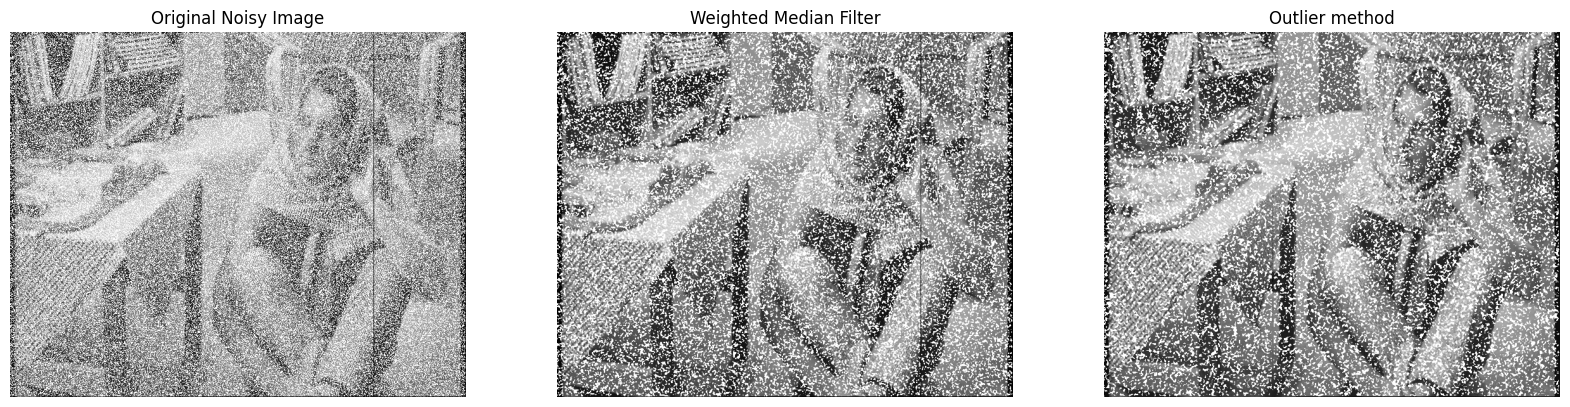

In [ ]:
# Hiển thị kết quả
plt.figure(figsize=(20, 5))  # Adjust figure size for better visualization

plt.subplot(1, 3, 1)  # 1 row, 4 columns, image 1
plt.title("Original Noisy Image")
plt.imshow(noisy_image_1, cmap="gray")
plt.axis("off")


plt.subplot(1, 3, 2)  # 1 row, 4 columns, image 3
plt.title("Weighted Median Filter")
plt.imshow(weighted_median_img, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)  # 1 row, 4 columns, image 4
plt.title("Outlier method")
plt.imshow(filtered_outlier_image, cmap="gray")
plt.axis("off")

plt.show()

### Bài 4

In [ ]:
def psnr_calculation_method(original_image, denoised_image):
  mse = np.mean((original_image - denoised_image) **2)
  if mse == 0:
    return float('inf')
  max_pixel = 255.0
  psnr = 10 * np.log10((max_pixel ** 2) / mse)
  return psnr

In [ ]:
psnr_median_value = psnr_calculation_method(noisy_image_1, filtered_median_blur_3x3)
psnr_weighted_median_value = psnr_calculation_method(noisy_image_1, weighted_median_img)
psnr_outlier_value = psnr_calculation_method(noisy_image_1, filtered_outlier_image)
print(f"PSNR for median value: {psnr_median_value:.2f} dB")
print(f"PSNR for weighted median value: {psnr_weighted_median_value:.2f} dB")
print(f"PSNR for outlier value: {psnr_outlier_value:.2f} dB")

PSNR for median value: 30.53 dB
PSNR for weighted median value: 31.87 dB
PSNR for outlier value: 30.34 dB


In [ ]:
def ssim_calculation_method(original_image, denoised_image):
  if len(original_image.shape) > 2:
      original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
  if len(denoised_image.shape) > 2:
      denoised_image = cv2.cvtColor(denoised_image, cv2.COLOR_BGR2GRAY)

  # Calculate SSIM using OpenCV's built-in function
  score = ssim(original_image, denoised_image)

  return score

In [ ]:
ssim_median_value = ssim_calculation_method(noisy_image_1, filtered_median_blur_3x3)
ssim_weighted_median_value = ssim_calculation_method(noisy_image_1, weighted_median_img)
ssim_outlier_value = ssim_calculation_method(noisy_image_1, filtered_outlier_image)
print(f"SSIM for median value: {ssim_median_value:.4f}")
print(f"SSIM for weighted median value: {ssim_weighted_median_value:.4f}")
print(f"SSIM for outlier value: {ssim_outlier_value:.4f}")

SSIM for median value: 0.0402
SSIM for weighted median value: 0.0456
SSIM for outlier value: 0.0412
